# RAG Retriever Optimization

Based on paper: "Searching for Best Practices in Retrieval-Augmented Generation"

This notebook optimizes the retriever component using the optimal chunk size (96 tokens) discovered in the previous experiment.

Tests 6 different retrieval methods and measures their impact on RAG performance using TRACe metrics.

## Step 1: Install Dependencies

In [1]:
!pip install -q python-dotenv datasets tiktoken langchain-core langchain-text-splitters langchain-huggingface langchain-chroma langchain-openai nltk


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Step 2: Import Libraries

In [2]:
import os
import json
import re
import numpy as np
import pandas as pd
import tiktoken
import shutil
import tempfile
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from datasets import load_dataset
from nltk.tokenize import sent_tokenize
import nltk
from typing import Callable

from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

nltk.download('punkt_tab', quiet=True)

load_dotenv()
openrouter_token = os.environ.get('OPENROUTER_TOKEN')

print("✓ All imports successful")

/Users/saikrishna/Desktop/Codespace/IIIT_AI_ML_course/Capstone_Project/reliablerag/.venv-1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All imports successful


## Step 3: Load Dataset & Setup Models

In [ ]:
import sys, os


def _add_ragbench_lib_to_path():
    for candidate in (os.getcwd(), os.path.join(os.getcwd(), "delucion_dataset")):
        if os.path.isdir(os.path.join(candidate, "ragbench_lib")) and candidate not in sys.path:
            sys.path.insert(0, candidate)
            return


_add_ragbench_lib_to_path()

from ragbench_lib.data_loading import load_rag_bench_data
from ragbench_lib.models import get_embedding_model, get_generation_llm, get_judge_llm
from ragbench_lib.generation_prompt import RAG_GENERATION_PROMPT
from ragbench_lib.vector_store import get_persist_dir, vector_store_names

print("Loading dataset...")
DATASET_NAME = "delucionqa"  # feeds both load_rag_bench_data() and vector store naming below
docs_df = load_rag_bench_data(DATASET_NAME, num_samples=50)
print(f"✓ Loaded {len(docs_df)} documents from {docs_df['row_id'].nunique()} unique questions")

# Setup models
embedding_model = get_embedding_model(openrouter_token)

llm = get_generation_llm(openrouter_token)

llama_judge = get_judge_llm(openrouter_token)

prompt = RAG_GENERATION_PROMPT

print("✓ Models configured")


## Step 4: Optimal Chunking (96 tokens)

In [ ]:
from ragbench_lib.chunking import count_tokens, encoding


def chunk_by_tokens(text, target_tokens, overlap_tokens):
    """Split text to achieve target token count per chunk"""
    tokens = encoding.encode(text)
    chunks = []
    
    i = 0
    while i < len(tokens):
        chunk_tokens = tokens[i : i + target_tokens]
        chunk_text = encoding.decode(chunk_tokens)
        if chunk_text.strip():
            chunks.append(chunk_text)
        i += target_tokens - overlap_tokens
    
    return chunks

def create_optimal_chunks(docs_df, chunk_size=96, overlap_fraction=0.1):
    """Create chunks using optimal 96-token size"""
    overlap_tokens = int(chunk_size * overlap_fraction)
    chunks = []
    
    for _, doc in docs_df.iterrows():
        splits = chunk_by_tokens(doc["text"], target_tokens=chunk_size, overlap_tokens=overlap_tokens)
        for chunk_idx, chunk_text in enumerate(splits):
            chunks.append(Document(
                page_content=chunk_text,
                metadata={
                    "chunk_id": f"{doc['doc_id']}_c{chunk_idx}",
                    "row_id": doc['row_id'],
                    "tokens": count_tokens(chunk_text)
                }
            ))
    
    return chunks

print("Preparing optimal chunks (96 tokens)...")
documents = create_optimal_chunks(docs_df)
print(f"✓ Created {len(documents)} chunks")

## Step 6: TRACe Evaluation Metrics

In [ ]:
from ragbench_lib.chunking import get_sentences
from ragbench_lib.trace_eval import (
    format_documents_with_keys,
    annotate_response_for_metrics as _annotate_response_for_metrics,
    compute_context_relevance,
    compute_utilization,
    compute_completeness,
    compute_adherence,
)


def annotate_response_for_metrics(documents, question, response):
    """Annotate a response using this notebook's judge LLM (llama_judge)."""
    return _annotate_response_for_metrics(llama_judge, documents, question, response)


print("✓ TRACe metric functions ready (ragbench_lib.trace_eval)")

## Step 7: Retriever Methods

In [ ]:
def create_similarity_retriever(documents, embedding_model, k=8):
    """R1: Simple Similarity Search (baseline)"""
    prefix, collection_name = vector_store_names(DATASET_NAME, "similarity")
    persist_dir = get_persist_dir(prefix)
    vector_store = Chroma.from_documents(
        documents=documents,
        embedding=embedding_model,
        collection_name=collection_name,
        persist_directory=persist_dir,
    )
    return vector_store.as_retriever(search_type="similarity", search_kwargs={"k": k})

def create_mmr_retriever(documents, embedding_model, k=8):
    """R2: Maximal Marginal Relevance (MMR) - balances relevance & diversity"""
    prefix, collection_name = vector_store_names(DATASET_NAME, "mmr")
    persist_dir = get_persist_dir(prefix)
    vector_store = Chroma.from_documents(
        documents=documents,
        embedding=embedding_model,
        collection_name=collection_name,
        persist_directory=persist_dir,
    )
    return vector_store.as_retriever(search_type="mmr", search_kwargs={"k": k})

def create_similarity_with_k_retriever(documents, embedding_model, k=12):
    """R3: Similarity Search with more results (k=12)"""
    prefix, collection_name = vector_store_names(DATASET_NAME, "similarity_k12")
    persist_dir = get_persist_dir(prefix)
    vector_store = Chroma.from_documents(
        documents=documents,
        embedding=embedding_model,
        collection_name=collection_name,
        persist_directory=persist_dir,
    )
    return vector_store.as_retriever(search_type="similarity", search_kwargs={"k": k})

def create_mmr_with_k_retriever(documents, embedding_model, k=12):
    """R4: MMR with more results (k=12)"""
    prefix, collection_name = vector_store_names(DATASET_NAME, "mmr_k12")
    persist_dir = get_persist_dir(prefix)
    vector_store = Chroma.from_documents(
        documents=documents,
        embedding=embedding_model,
        collection_name=collection_name,
        persist_directory=persist_dir,
    )
    return vector_store.as_retriever(search_type="mmr", search_kwargs={"k": k})

def create_similarity_k16_retriever(documents, embedding_model, k=16):
    """R5: Similarity Search with even more results (k=16)"""
    prefix, collection_name = vector_store_names(DATASET_NAME, "similarity_k16")
    persist_dir = get_persist_dir(prefix)
    vector_store = Chroma.from_documents(
        documents=documents,
        embedding=embedding_model,
        collection_name=collection_name,
        persist_directory=persist_dir,
    )
    return vector_store.as_retriever(search_type="similarity", search_kwargs={"k": k})

def create_mmr_k16_retriever(documents, embedding_model, k=16):
    """R6: MMR with k=16 for maximum coverage"""
    prefix, collection_name = vector_store_names(DATASET_NAME, "mmr_k16")
    persist_dir = get_persist_dir(prefix)
    vector_store = Chroma.from_documents(
        documents=documents,
        embedding=embedding_model,
        collection_name=collection_name,
        persist_directory=persist_dir,
    )
    return vector_store.as_retriever(search_type="mmr", search_kwargs={"k": k})

print("✓ Retriever methods ready")

## Step 8: Experiment Runner

In [7]:
def run_retriever_experiment(retriever_name: str, retriever_func: Callable, documents, 
                             docs_df, embedding_model, llm, prompt, num_samples=5):
    """Run experiment for a specific retriever method"""
    print(f"  Testing {retriever_name:30s}...", end=" ")
    
    try:
        # Create retriever
        retriever = retriever_func(documents, embedding_model)
        
        # Build RAG chain
        def format_docs(docs):
            return "\n\n".join(doc.page_content for doc in docs)
        
        rag_chain = ({"context": retriever | format_docs, "question": RunnablePassthrough()} 
                     | prompt | llm | StrOutputParser())
        
        # Run evaluation
        unique_samples = docs_df.drop_duplicates(subset=['row_id']).head(num_samples).reset_index(drop=True)
        results = []
        
        for i, row in unique_samples.iterrows():
            try:
                question = row['question']
                my_response = rag_chain.invoke(question)
                retrieved_docs = retriever.invoke(question)
                retrieved_texts = [doc.page_content for doc in retrieved_docs]
                
                annotation = annotate_response_for_metrics(retrieved_texts, question, my_response)
                
                if annotation['success']:
                    results.append({
                        'context_relevance': compute_context_relevance(retrieved_texts, annotation),
                        'utilization': compute_utilization(retrieved_texts, annotation),
                        'completeness': compute_completeness(annotation),
                        'adherence': compute_adherence(annotation),
                    })
            except Exception as e:
                pass
        
        if results:
            avg_metrics = {
                'retriever': retriever_name,
                'context_relevance': np.mean([r['context_relevance'] for r in results]),
                'utilization': np.mean([r['utilization'] for r in results]),
                'completeness': np.mean([r['completeness'] for r in results]),
                'adherence': np.mean([r['adherence'] for r in results]),
            }
            print(f"✓ (CR: {avg_metrics['context_relevance']:.4f})")
            return avg_metrics
        else:
            print("✗ No results")
            return None
    except Exception as e:
        print(f"✗ Error: {str(e)[:40]}")
        return None

print("✓ Experiment runner ready")

✓ Experiment runner ready


## Step 9: Run Retriever Optimization

In [8]:
retrievers = [
    ("R1: Similarity (k=8)", create_similarity_retriever),
    ("R2: MMR (k=8)", create_mmr_retriever),
    ("R3: Similarity (k=12)", create_similarity_with_k_retriever),
    ("R4: MMR (k=12)", create_mmr_with_k_retriever),
    ("R5: Similarity (k=16)", create_similarity_k16_retriever),
    ("R6: MMR (k=16)", create_mmr_k16_retriever),
]

print("\n" + "="*100)
print("RETRIEVER OPTIMIZATION (Using Optimal 96-Token Chunks)")
print("Testing 6 retrieval methods with different search strategies and k values")
print("="*100 + "\n")

retriever_results = []

for retriever_name, retriever_func in retrievers:
    result = run_retriever_experiment(retriever_name, retriever_func, documents, 
                                      docs_df, embedding_model, llm, prompt, num_samples=5)
    if result:
        retriever_results.append(result)

print("\n" + "="*100)
print("RESULTS TABLE")
print("="*100)

if retriever_results:
    df_results = pd.DataFrame(retriever_results)
    display(df_results)
    
    best_idx = df_results['context_relevance'].idxmax()
    best_result = df_results.iloc[best_idx]
    
    print("\n" + "-"*100)
    print(f"🏆 OPTIMAL RETRIEVER: {best_result['retriever']}")
    print("-"*100)
    print(f"  Context Relevance:  {best_result['context_relevance']:.4f}")
    print(f"  Utilization:        {best_result['utilization']:.4f}")
    print(f"  Completeness:       {best_result['completeness']:.4f}")
    print(f"  Adherence:          {best_result['adherence']:.4f}")
    print("-"*100)
else:
    print("No results collected")


RETRIEVER OPTIMIZATION (Using Optimal 96-Token Chunks)
Testing 6 retrieval methods with different search strategies and k values

  Testing R1: Similarity (k=8)          ... ✓ (CR: 0.1346)
  Testing R2: MMR (k=8)                 ... ✓ (CR: 0.1181)
  Testing R3: Similarity (k=12)         ... ✓ (CR: 0.1595)
  Testing R4: MMR (k=12)                ... ✓ (CR: 0.0782)
  Testing R5: Similarity (k=16)         ... ✓ (CR: 0.0980)
  Testing R6: MMR (k=16)                ... ✓ (CR: 0.0602)

RESULTS TABLE


,retriever,context_relevance,utilization,completeness,adherence
0,R1: Similarity (k=8),0.13456,0.04500,0.33332,0.8
1,R2: MMR (k=8),0.11808,0.08216,0.63332,1.0
2,R3: Similarity (k=12),0.15950,0.04728,0.42500,0.8
3,R4: MMR (k=12),0.07818,0.04252,0.63334,0.8
4,R5: Similarity (k=16),0.09804,0.06452,0.53666,0.8
5,R6: MMR (k=16),0.06020,0.02598,0.48094,0.8



----------------------------------------------------------------------------------------------------
🏆 OPTIMAL RETRIEVER: R3: Similarity (k=12)
----------------------------------------------------------------------------------------------------
  Context Relevance:  0.1595
  Utilization:        0.0473
  Completeness:       0.4250
  Adherence:          0.8000
----------------------------------------------------------------------------------------------------


## Step 10: Visualize Results

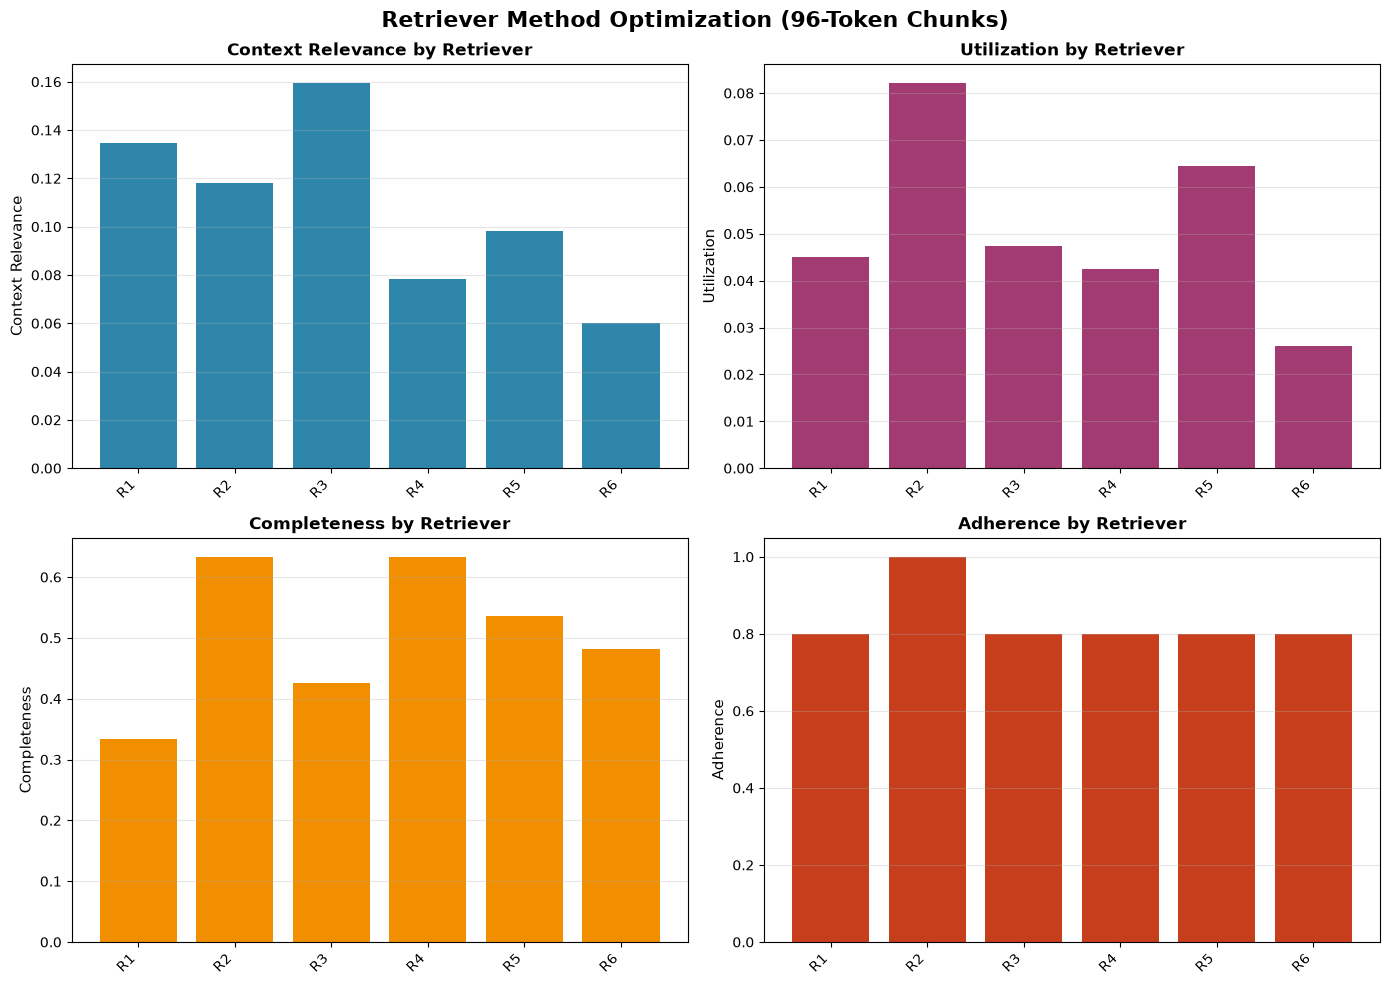


✓ Visualization complete


In [9]:
if retriever_results:
    df_results = pd.DataFrame(retriever_results)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Retriever Method Optimization (96-Token Chunks)', fontsize=16, fontweight='bold')
    
    x_pos = np.arange(len(df_results))
    
    # Context Relevance
    axes[0, 0].bar(x_pos, df_results['context_relevance'], color='#2E86AB')
    axes[0, 0].set_ylabel('Context Relevance', fontsize=11)
    axes[0, 0].set_title('Context Relevance by Retriever', fontsize=12, fontweight='bold')
    axes[0, 0].set_xticks(x_pos)
    axes[0, 0].set_xticklabels([r.split(':')[0] for r in df_results['retriever']], rotation=45, ha='right')
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # Utilization
    axes[0, 1].bar(x_pos, df_results['utilization'], color='#A23B72')
    axes[0, 1].set_ylabel('Utilization', fontsize=11)
    axes[0, 1].set_title('Utilization by Retriever', fontsize=12, fontweight='bold')
    axes[0, 1].set_xticks(x_pos)
    axes[0, 1].set_xticklabels([r.split(':')[0] for r in df_results['retriever']], rotation=45, ha='right')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Completeness
    axes[1, 0].bar(x_pos, df_results['completeness'], color='#F18F01')
    axes[1, 0].set_ylabel('Completeness', fontsize=11)
    axes[1, 0].set_title('Completeness by Retriever', fontsize=12, fontweight='bold')
    axes[1, 0].set_xticks(x_pos)
    axes[1, 0].set_xticklabels([r.split(':')[0] for r in df_results['retriever']], rotation=45, ha='right')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Adherence
    axes[1, 1].bar(x_pos, df_results['adherence'], color='#C73E1D')
    axes[1, 1].set_ylabel('Adherence', fontsize=11)
    axes[1, 1].set_title('Adherence by Retriever', fontsize=12, fontweight='bold')
    axes[1, 1].set_xticks(x_pos)
    axes[1, 1].set_xticklabels([r.split(':')[0] for r in df_results['retriever']], rotation=45, ha='right')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Visualization complete")

## Step 11: Summary & Comparison

In [10]:
if retriever_results:
    df_results = pd.DataFrame(retriever_results).sort_values('context_relevance', ascending=False)
    
    print("\n" + "="*100)
    print("RETRIEVER RANKING (by Context Relevance)")
    print("="*100)
    
    for idx, (i, row) in enumerate(df_results.iterrows(), 1):
        medal = "🥇" if idx == 1 else "🥈" if idx == 2 else "🥉" if idx == 3 else "  "
        print(f"{medal} {idx}. {row['retriever']:30s} | CR: {row['context_relevance']:.4f} | Util: {row['utilization']:.4f} | Compl: {row['completeness']:.4f} | Adh: {row['adherence']:.4f}")
    
    print("\n" + "="*100)
    print("KEY INSIGHTS")
    print("="*100)
    print(f"• Best retriever: {df_results.iloc[0]['retriever']}")
    print(f"• Highest context relevance: {df_results.iloc[0]['context_relevance']:.4f}")
    print(f"• Best trade-off between relevance and completeness: {df_results.iloc[0]['retriever']}")
    print("="*100)


RETRIEVER RANKING (by Context Relevance)
🥇 1. R3: Similarity (k=12)          | CR: 0.1595 | Util: 0.0473 | Compl: 0.4250 | Adh: 0.8000
🥈 2. R1: Similarity (k=8)           | CR: 0.1346 | Util: 0.0450 | Compl: 0.3333 | Adh: 0.8000
🥉 3. R2: MMR (k=8)                  | CR: 0.1181 | Util: 0.0822 | Compl: 0.6333 | Adh: 1.0000
   4. R5: Similarity (k=16)          | CR: 0.0980 | Util: 0.0645 | Compl: 0.5367 | Adh: 0.8000
   5. R4: MMR (k=12)                 | CR: 0.0782 | Util: 0.0425 | Compl: 0.6333 | Adh: 0.8000
   6. R6: MMR (k=16)                 | CR: 0.0602 | Util: 0.0260 | Compl: 0.4809 | Adh: 0.8000

KEY INSIGHTS
• Best retriever: R3: Similarity (k=12)
• Highest context relevance: 0.1595
• Best trade-off between relevance and completeness: R3: Similarity (k=12)
